# Build a model to predict Koc 

The aim of this assignment is to build a model that can predict the soil sorption coefficient logKoc. In contrast to the previous assignment, this time the goal is outperform the state-of-the-art OPERA Koc model:

 - Paper on OPERA models, including the one for Koc: https://doi.org/10.1186/s13321-018-0263-1
 - Performance of the OPERA Koc model on the test set: R2 = 0.71, RMSE = 0.61
 - Model: weighted k-Nearest Neighbors regressor trained on 12 selected PaDEL descriptors (similar to RDKit descriptors)

As you are now a modelling expert, it is open to you which model architecture you use. BUT we ask you to justify your choices! 


#### Tasks:

1) Load the training data and split it into train and test according to the 'Tr_1_Tst_0' column

2) Think about a suitable architecture:
    - Suitable descriptors/fingerprints
    - Model choice (fine-tune a pretrained neural network? GNN? Ensemble method? Gaussian Process? ...?)
    - Consider providing an AD for your model (using an AD metric, or by defining the content of the training data (e.g., organic chemicals with a MW between x and y)
    - Consider providing prediction uncertainty: If you decide to do so, provide uncertainty calibration. If not, explain why.
    
        
3) Train the model on the same training data used in the paper (Tr_1_Tst_0 == 1). 

4) Consider tuning hyperparameters (e.g., using GridSearchCV and on a short list of parameters) 

5) Evaluate model on the test set (Tr_1_Tst_0 == 0), ONLY ONCE ! 

6) Compare your model performance on the test set to the OPERA model. 

#### Questions:
1) Which architecture did you choose, and why?
2) How well does your model perform on the test set? Could you outperform OPERA?
3) Did you add prediction uncertainty, and why? Are the uncertainties well calibrated?
4) Do you provide an AD, and why? How did you define your AD


In [1]:
# import
import pandas as pd
import numpy as np
from rdkit import Chem
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt
import seaborn as sns

#### 1. Load training data

In [2]:
# Loading the data from the .sdf file
supplier = Chem.SDMolSupplier("C:\\Users\\Startklar\\DSA104\\assignments\\assignment10\\KOC_QR.sdf")
df = pd.DataFrame([
    {
        "SMILES": Chem.MolToSmiles(m),
        **{p: m.GetProp(p) for p in ['preferred_name', 'LogKOC', 'Tr_1_Tst_0']}
    }
    for m in supplier if m is not None
])

In [3]:
# The data is pre-split in training and testing:
df.groupby('Tr_1_Tst_0').count()

,SMILES,preferred_name,LogKOC
Tr_1_Tst_0,,,
0,184,184,184
1,544,544,544


In [4]:
df.head()

,SMILES,preferred_name,LogKOC,Tr_1_Tst_0
0,Clc1ccc(C(c2ccc(Cl)cc2)C(Cl)(Cl)Cl)cc1,"p,p'-DDT",5.31,1
1,c1ccc2c(c1)cc1ccc3cccc4ccc2c1c34,Benzo(a)pyrene,5.95,1
2,O=C(Nc1ccc([N+](=O)[O-])cc1Cl)c1cc(Cl)ccc1O,Niclosamide,3.35,1
3,COc1ccc(NC(C)=O)cc1,N-(4-Methoxyphenyl)acetamide,1.4,0
4,COP(=O)(OC)C(O)C(Cl)(Cl)Cl,Trichlorfon,1.9,1


#### 2. Build a supervised model of your choice

In [5]:
# Encoding molecules from SMILES - Using MACCS

from utils import maccs_fp_from_smiles # import function from utils
from utils import compute_descriptors # import function from utils

smiles = df['SMILES'].values # Structures (SMILES)

X, idx = maccs_fp_from_smiles(smiles) # Calculate fingerprints (MACCS)

descriptor_df = df["SMILES"].apply(compute_descriptors) # calcl descriptors

df_full = pd.concat([df, descriptor_df], axis=1) # combining dfs
df_full = df_full.dropna().reset_index(drop=True)

# Convert MACCS numpy array to dataframe
maccs_df = pd.DataFrame(
    X,
    columns=[f"MACCS_{i}" for i in range(X.shape[1])]
)

X_df = pd.concat([maccs_df, descriptor_df], axis=1) # final df

# Double checking that both df have same number of rows
valid_rows = X_df.dropna().index
X_df = X_df.loc[valid_rows].reset_index(drop=True)
df_full = df_full.loc[valid_rows].reset_index(drop=True)

y = df_full["LogKOC"].values # Target variable

df_full.head()

,SMILES,preferred_name,LogKOC,Tr_1_Tst_0,MolWt,LogP,EState_VSA5,TPSA,NumHAcc,NumAromaticRings,HeavyAtomCount,RingCount,qed,NumHDonors,NOCount
0,Clc1ccc(C(c2ccc(Cl)cc2)C(Cl)(Cl)Cl)cc1,"p,p'-DDT",5.31,1,354.491,6.4955,0.000000,0.00,0.0,2.0,19.0,2.0,0.540334,0.0,0.0
1,c1ccc2c(c1)cc1ccc3cccc4ccc2c1c34,Benzo(a)pyrene,5.95,1,252.316,5.7372,43.089794,0.00,0.0,5.0,20.0,5.0,0.243454,0.0,0.0
2,O=C(Nc1ccc([N+](=O)[O-])cc1Cl)c1cc(Cl)ccc1O,Niclosamide,3.35,1,327.123,3.8595,30.331835,92.47,4.0,2.0,21.0,2.0,0.661180,2.0,6.0
3,COc1ccc(NC(C)=O)cc1,N-(4-Methoxyphenyl)acetamide,1.4,0,165.192,1.6536,6.923737,38.33,2.0,1.0,12.0,1.0,0.723213,1.0,3.0
4,COP(=O)(OC)C(O)C(Cl)(Cl)Cl,Trichlorfon,1.9,1,257.437,2.1609,0.000000,55.76,4.0,0.0,12.0,0.0,0.621638,1.0,4.0


In [6]:
# Train test split
X_train_full = X_df[df_full["Tr_1_Tst_0"] == "1"]
X_test = X_df[df_full["Tr_1_Tst_0"] == "0"]

y_train_full = df_full.loc[df_full["Tr_1_Tst_0"] == "1", "LogKOC"]
y_test = df_full.loc[df_full["Tr_1_Tst_0"] == "0", "LogKOC"]

In [7]:
# Making internal train/test split too see performance (technically a validation set)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=42
)

## Using two models, XGBoost (not in DSA104 environement) and normal GradientBoost.

### First XGBoost, again this model not in DSA104 environment, would need to download package for the code to work

In [8]:
# Model
from xgboost import XGBRegressor

XGBoost = XGBRegressor(
    n_estimators=250,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

XGBoost.fit(X_train, y_train)

XGBoost_y_val_pred = XGBoost.predict(X_val)

# Check performance
print("OPERA Koc model on the test set: R² = 0.71, RMSE = 0.61")
print("Test R²:", r2_score(y_val, XGBoost_y_val_pred))
print("Test RMSE:", root_mean_squared_error(y_val, XGBoost_y_val_pred))

OPERA Koc model on the test set: R² = 0.71, RMSE = 0.61
Test R²: 0.7772656679153442
Test RMSE: 0.5981654524803162


Tuning hyperparameters

In [9]:
param_dist = {
    "n_estimators": [100, 200, 300, 500, 800, 1000],
    "learning_rate": [0.005, 0.01, 0.02, 0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4, 5, 6],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 2, 3, 5, 10],
    "gamma": [0, 0.01, 0.1, 0.5, 1],
    "reg_alpha": [0, 0.001, 0.01, 0.1, 1],
    "reg_lambda": [0.1, 1, 5, 10, 20]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

xgb_search = RandomizedSearchCV(
    estimator=XGBoost,
    param_distributions=param_dist,
    n_iter=100,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)

print("Best parameters:")
print(xgb_search.best_params_)

print("Best CV RMSE:")
print(-xgb_search.best_score_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best parameters:
{'subsample': 0.8, 'reg_lambda': 10, 'reg_alpha': 0.001, 'n_estimators': 1000, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.02, 'gamma': 0.1, 'colsample_bytree': 0.6}
Best CV RMSE:
0.571141642332077


In [10]:
best_xgb = xgb_search.best_estimator_

best_xgb.fit(X_train, y_train)

best_xgb_val_pred = best_xgb.predict(X_val)

# Check performance
print("OPERA Koc model on the test set: R² = 0.71, RMSE = 0.61")
print("Test R²:", r2_score(y_val, best_xgb_val_pred))
print("Test RMSE:", root_mean_squared_error(y_val, best_xgb_val_pred))

OPERA Koc model on the test set: R² = 0.71, RMSE = 0.61
Test R²: 0.7875266075134277
Test RMSE: 0.5842247605323792


##### Chose kNN as a AD

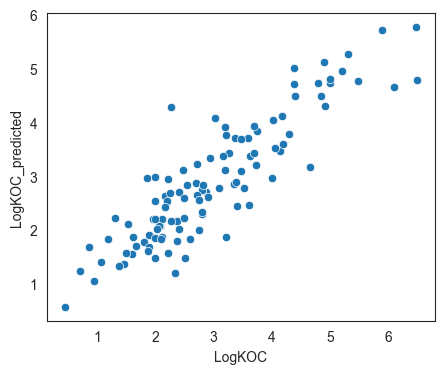

In [11]:
nbrs = NearestNeighbors(n_neighbors=5)
nbrs.fit(X_train)

dist, _ = nbrs.kneighbors(X_val)
knn_dist = dist.mean(axis=1)

y_val_numeric = pd.to_numeric(y_val).reset_index(drop=True)

df_val_XGB = pd.DataFrame({'LogKOC': y_val_numeric,
                        'LogKOC_predicted': best_xgb_val_pred,
                        'Error': np.abs(y_val_numeric - best_xgb_val_pred),
                        'kNN_Distance': knn_dist
                        })
plt.figure(figsize=(5, 4))
sns.set_style('white')
sns.scatterplot(data=df_val_XGB, x='LogKOC', y='LogKOC_predicted')
plt.show()

Evaluation of model

Average of average distances: 
Validation:: 14.691842152696331 



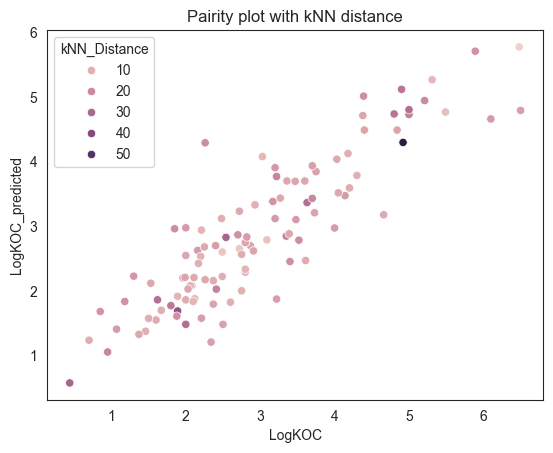

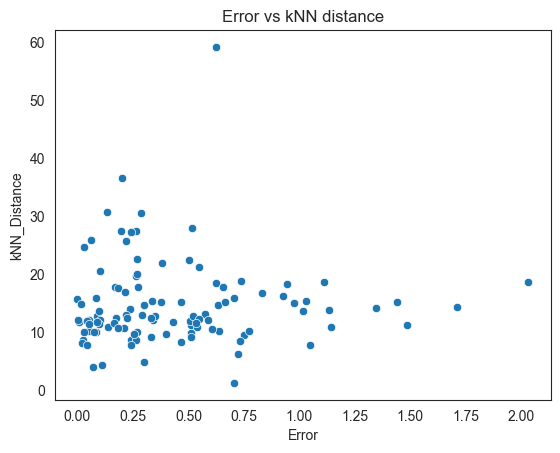

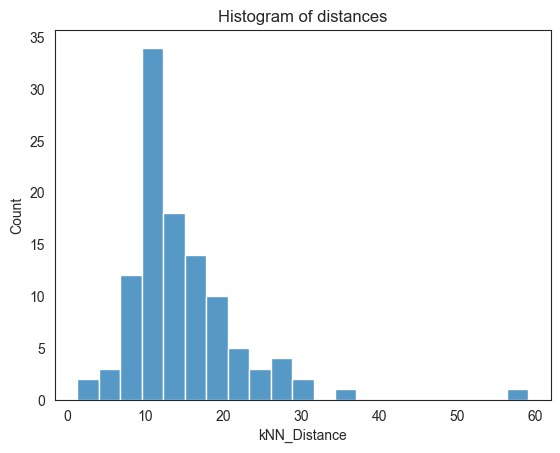

In [12]:
print(f'Average of average distances: \n'
      f'Validation:: {knn_dist.mean()} \n')

sns.scatterplot(df_val_XGB, x='LogKOC', y='LogKOC_predicted', hue='kNN_Distance')
plt.title('Pairity plot with kNN distance')
plt.show()
sns.scatterplot(df_val_XGB, x='Error', y='kNN_Distance')
plt.title('Error vs kNN distance')
plt.show()
sns.histplot(df_val_XGB, x='kNN_Distance')
plt.title('Histogram of distances')
plt.show()

### Now GradientBoosting

In [13]:
GradientBoost = GradientBoostingRegressor(
    n_estimators=240,
    learning_rate=0.02,
    max_depth=3,
    random_state=42
)

GradientBoost.fit(X_train, y_train)

GradientBoost_y_val_pred = GradientBoost.predict(X_val)

# Check performance
print("OPERA Koc model on the test set: R² = 0.71, RMSE = 0.61")
print("Test R²:", r2_score(y_val, GradientBoost_y_val_pred))
print("Test RMSE:", root_mean_squared_error(y_val, GradientBoost_y_val_pred))

OPERA Koc model on the test set: R² = 0.71, RMSE = 0.61
Test R²: 0.7673555334102258
Test RMSE: 0.6113276828387681


Hyperparameter tuning

In [14]:
param_dist = {
    "n_estimators": [100, 200, 300, 500, 800, 1000],
    "learning_rate": [0.005, 0.01, 0.02, 0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4, 5],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features": [None, "sqrt", "log2"],
    "loss": ["squared_error", "absolute_error", "huber"]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=GradientBoost,
    param_distributions=param_dist,
    n_iter=100,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print("Best parameters:")
print(search.best_params_)

print("Best CV RMSE:")
print(-search.best_score_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best parameters:
{'subsample': 0.7, 'n_estimators': 800, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 4, 'loss': 'huber', 'learning_rate': 0.03}
Best CV RMSE:
0.5637072736780773


In [15]:
best_GB = search.best_estimator_

best_GB.fit(X_train, y_train)

GradientBoost_best_y_val_pred = best_GB.predict(X_val)

# Check performance
print("OPERA Koc model on the test set: R² = 0.71, RMSE = 0.61")
print("Test R²:", r2_score(y_val, GradientBoost_best_y_val_pred))
print("Test RMSE:", root_mean_squared_error(y_val, GradientBoost_best_y_val_pred))

OPERA Koc model on the test set: R² = 0.71, RMSE = 0.61
Test R²: 0.7713663232034151
Test RMSE: 0.6060351292047703


kNN as AD

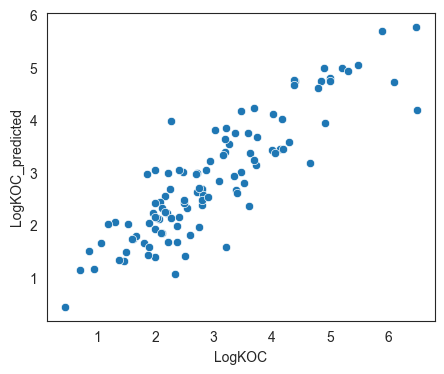

In [16]:
df_val_GB = pd.DataFrame({'LogKOC': y_val_numeric,
                        'LogKOC_predicted': GradientBoost_best_y_val_pred,
                        'Error': np.abs(y_val_numeric - GradientBoost_best_y_val_pred),
                        'kNN_Distance': knn_dist
                        })
plt.figure(figsize=(5, 4))
sns.set_style('white')
sns.scatterplot(data=df_val_GB, x='LogKOC', y='LogKOC_predicted')
plt.show()

Average of average distances: 
Validation: 14.691842152696331 



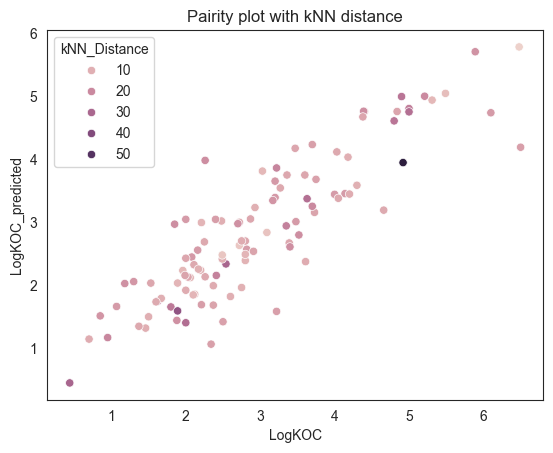

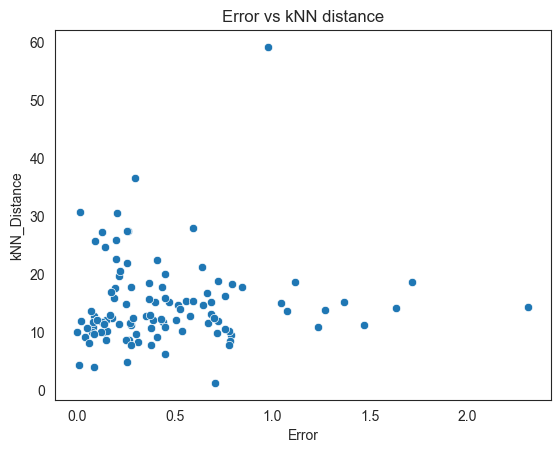

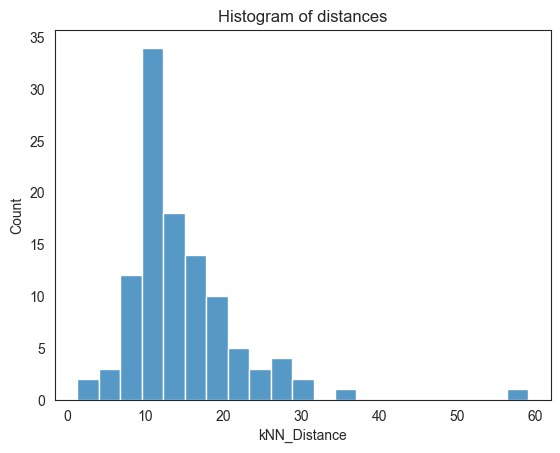

In [17]:
print(f'Average of average distances: \n'
      f'Validation: {knn_dist.mean()} \n')

sns.scatterplot(df_val_GB, x='LogKOC', y='LogKOC_predicted', hue='kNN_Distance')
plt.title('Pairity plot with kNN distance')
plt.show()
sns.scatterplot(df_val_GB, x='Error', y='kNN_Distance')
plt.title('Error vs kNN distance')
plt.show()
sns.histplot(df_val_GB, x='kNN_Distance')
plt.title('Histogram of distances')
plt.show()

#### 3. Model performance on test set
--> **TEST ONLY ONCE !**

In [18]:
GB_test_pred = best_GB.predict(X_test)
XGB_test_pred = best_xgb.predict(X_test)    

# Check performance
print("OPERA Koc model on the test set: R² = 0.71, RMSE = 0.61")
print("-------------------------------------------------------------")
print("Gradient Boosting")
print("Test R²:", f"{r2_score(y_test, GB_test_pred):.4f}")
print("Test RMSE:", f"{root_mean_squared_error(y_test, GB_test_pred):.4f}")
print("------------------------------------------------------------")
print("XGBoost")
print("Test R²:", f"{r2_score(y_test, XGB_test_pred,):.4f}")
print("Test RMSE:", f"{root_mean_squared_error(y_test, XGB_test_pred):.4f}")

OPERA Koc model on the test set: R² = 0.71, RMSE = 0.61
-------------------------------------------------------------
Gradient Boosting
Test R²: 0.7919
Test RMSE: 0.5214
------------------------------------------------------------
XGBoost
Test R²: 0.8126
Test RMSE: 0.4947


In [19]:
y_test_numeric = pd.to_numeric(y_test).reset_index(drop=True)

nbrs.fit(X_train_full)

dist_test, _ = nbrs.kneighbors(X_test)
knn_dist_test = dist_test.mean(axis=1)

df_test = pd.DataFrame({'LogKOC': y_test_numeric,
                        'LogKOC_predicted_GB': GB_test_pred,
                        'LogKOC_predicted_XGB': XGB_test_pred,
                        'Error_GB': np.abs(y_test_numeric - GB_test_pred),
                        'Error_XGB': np.abs(y_test_numeric - XGB_test_pred),
                        "kNN_distance": knn_dist_test
                        })

ad_threshold = np.percentile(knn_dist, 95)

df_test["inside_AD"] = df_test["kNN_distance"] <= ad_threshold
df_test.groupby("inside_AD")[["Error_GB", "Error_XGB"]].agg(["count", "mean", "median", "std"])

Error_GB                               Error_XGB            \
             count      mean    median       std     count      mean   
inside_AD                                                              
False            7  0.526495  0.220149  0.639035         7  0.459346   
True           177  0.376843  0.268191  0.341275       177  0.375324   

                               
             median       std  
inside_AD                      
False      0.487873  0.432767  
True       0.302012  0.315342

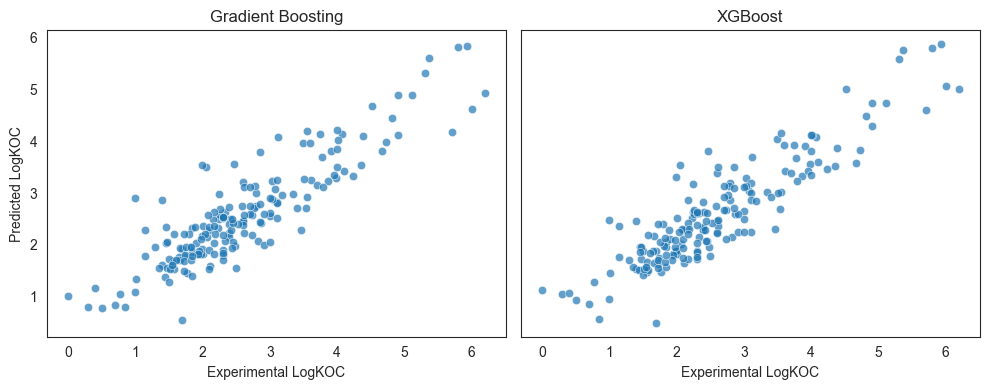

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

sns.set_style("white")

# Gradient Boosting
sns.scatterplot(
    data=df_test,
    x="LogKOC",
    y="LogKOC_predicted_GB",
    ax=axes[0],
    alpha=0.7
)

axes[0].set_title("Gradient Boosting")
axes[0].set_xlabel("Experimental LogKOC")
axes[0].set_ylabel("Predicted LogKOC")

# XGBoost
sns.scatterplot(
    data=df_test,
    x="LogKOC",
    y="LogKOC_predicted_XGB",
    ax=axes[1],
    alpha=0.7
)

axes[1].set_title("XGBoost")
axes[1].set_xlabel("Experimental LogKOC")
axes[1].set_ylabel("Predicted LogKOC")

plt.tight_layout()
plt.show()

### Results

OPERA Koc model on the test set: R² = 0.71, RMSE = 0.61

**Gradient Boosting**
Test R²: 0.7919
Test RMSE: 0.5214

**XGBoost**
Test R²: 0.8126
Test RMSE: 0.4947

#### Questions:
1) Which architecture did you choose, and why?
2) How well does your model perform on the test set? Could you outperform OPERA?
3) Did you add prediction uncertainty, and why? Are the uncertainties well calibrated?
4) Do you provide an AD, and why? How did you define your AD

**Answers:**

1. Since the dataset size is limited, I didnt consider using a NN as I thought it wouldnt really perform well and lead to overfitting. Ensemble methods like the ones I chose usually work pretty well with smaller data sizes, thats why I chose them. I chose specifically XGBoost because I saw it being used in a paper and wanted to try it, thats also the reason why I also chose Greadient Boosting as it is one we have available in the DSA104 environment.
2. I mean I dont know if I made any mistakes along the way but I got decent results. ButI dont know if it could outperform OPERA. But I would say its a pretty good model. The hyperparameter tuning also improved the model which was nice to see.
3. I did not include uncertainity.
4. I did include an AD, kNN to be exact. Intially I wanted to use tanimoto but then I opted for kNN as jasmin used in the solution of 9 and it was also about logKOC and thought it might be appropriate to use it. I included it to have a sense about the model and defined it based on the 95% percentile of the mean kNN distance which was around 22 I think. Using the code which was provided with solution 9 of the Histogram of distances I wouldve also chose a number around that region. The error outside was also higher than inside which was also good to see.